# Clustering

## 0. Imports

In [313]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import itertools
from itertools import product

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [314]:
df = pd.read_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/regression.csv')
display(df)

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,-64.400000
1,user_10,20,89.0,-74.800000
2,user_14,61,143.0,-159.000000
3,user_17,51,47.0,-61.600000
4,user_18,5,3.0,-5.666667
5,user_19,118,16.0,-98.750000
6,user_21,65,10.0,-95.500000
7,user_25,79,179.0,-92.600000
8,user_28,60,149.0,-86.400000
9,user_3,18,317.0,-105.400000


In [315]:
df = df.drop(columns=['pageviews', 'uid'])
display(df)

,num_commits,AVG(diff)
0,62,-64.400000
1,20,-74.800000
2,61,-159.000000
3,51,-61.600000
4,5,-5.666667
5,118,-98.750000
6,65,-95.500000
7,79,-92.600000
8,60,-86.400000
9,18,-105.400000


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [316]:
kmeans = KMeans(n_clusters=3, random_state=21)
labels = kmeans.fit_predict(df)
display(labels)

array([0, 0, 1, 0, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 2, 1, 0, 1, 1], dtype=int32)

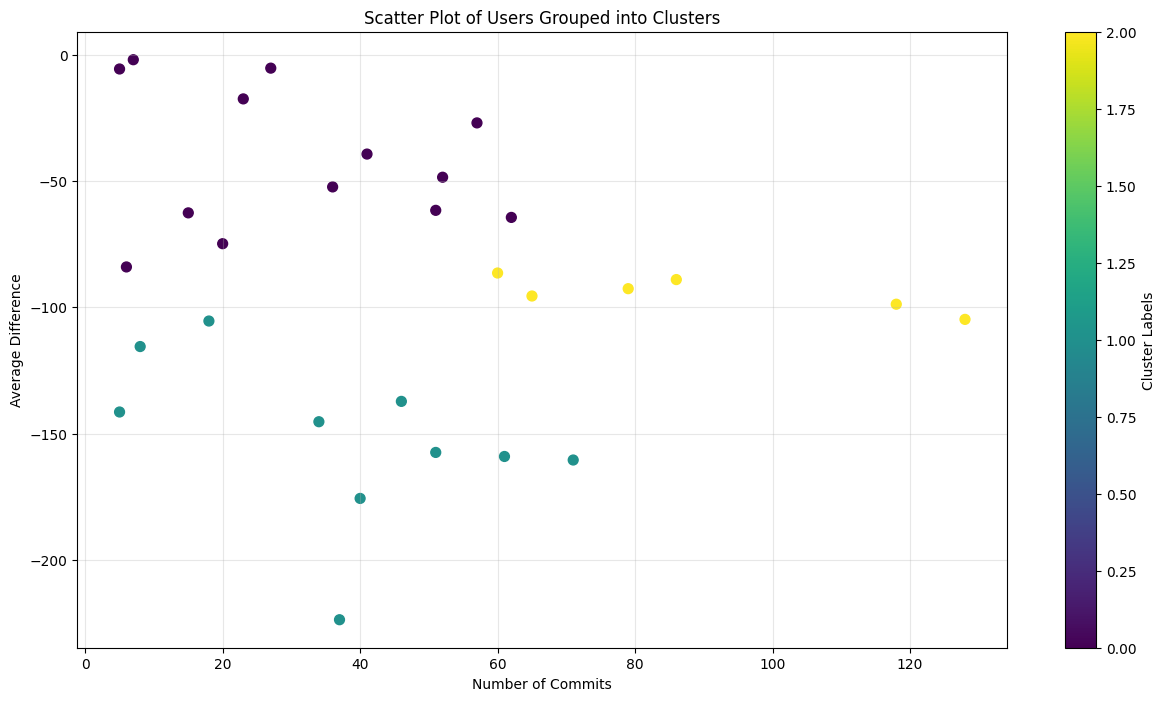

In [317]:
plt.figure(figsize=(15, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis', s=50)
plt.xlabel('Number of Commits')
plt.ylabel('Average Difference')
plt.title('Scatter Plot of Users Grouped into Clusters')
plt.colorbar(label='Cluster Labels')
plt.grid(True, alpha=0.3)
plt.show()

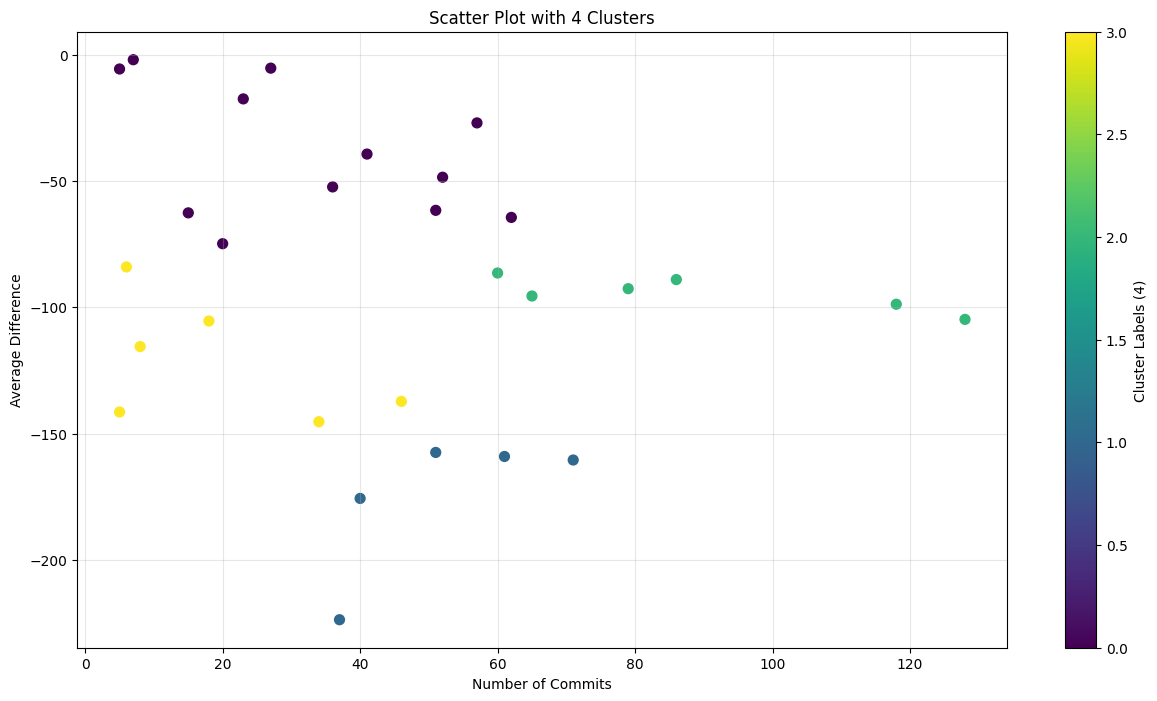

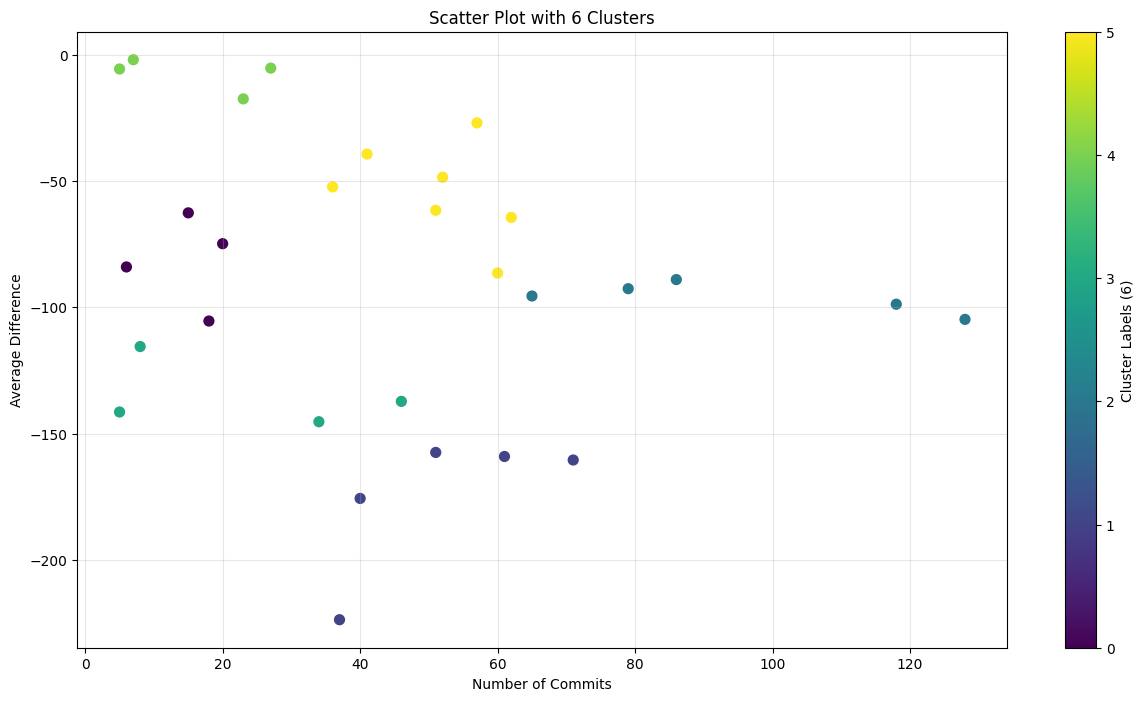

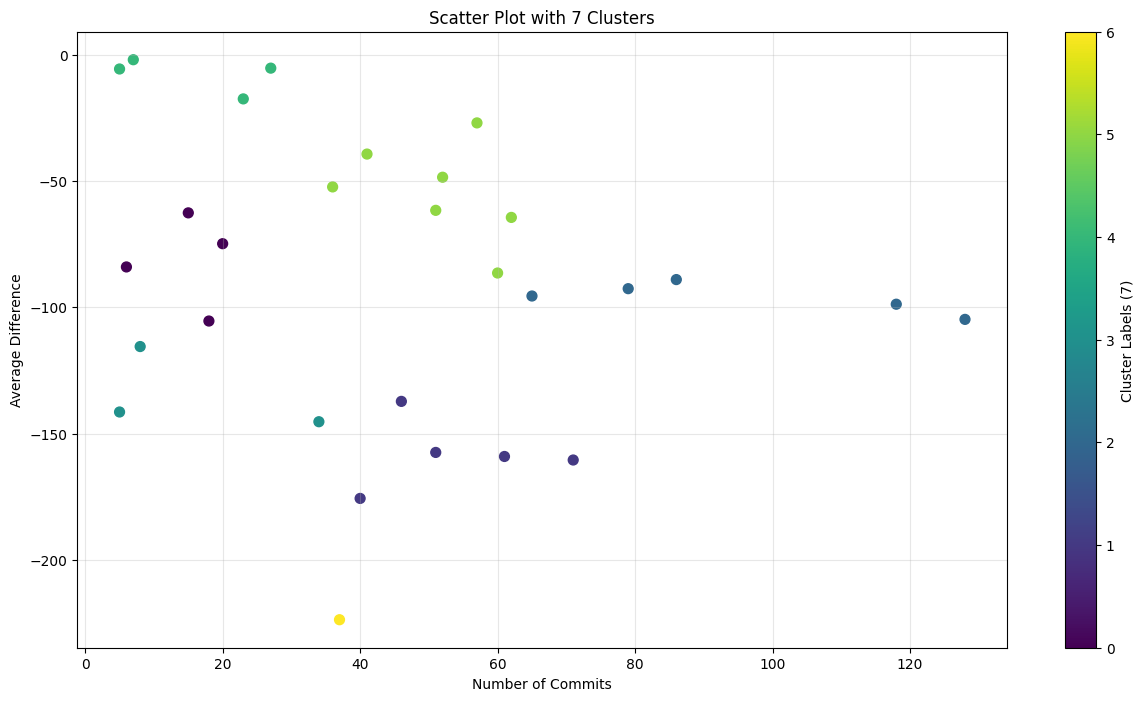

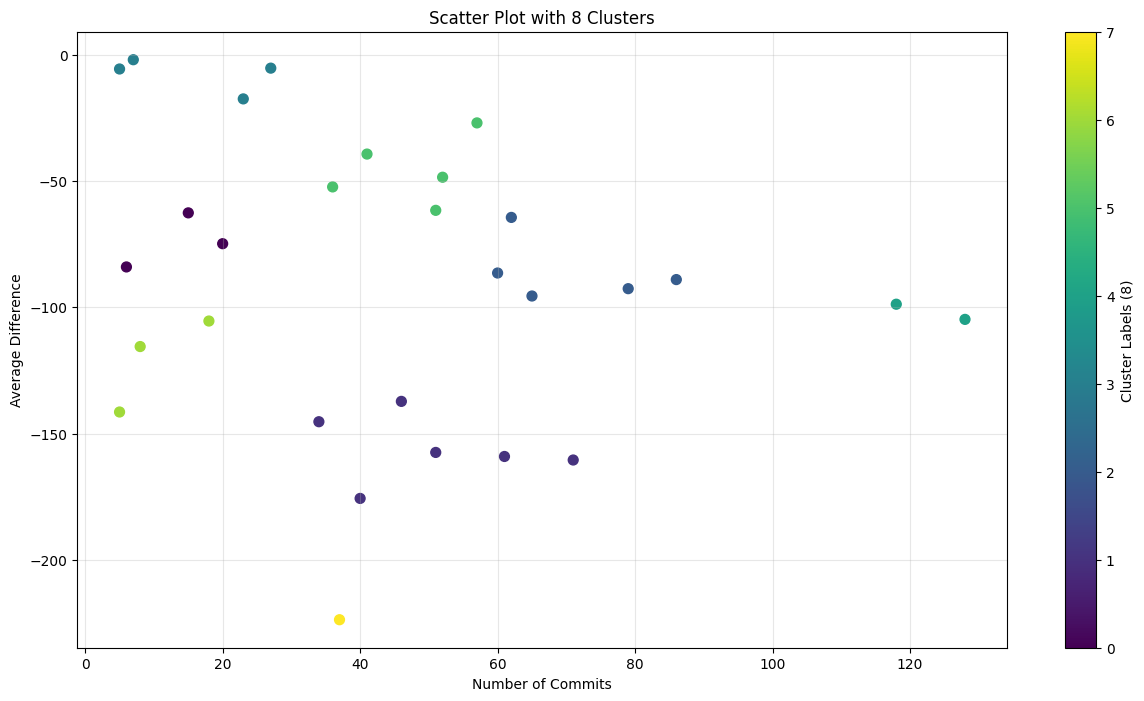

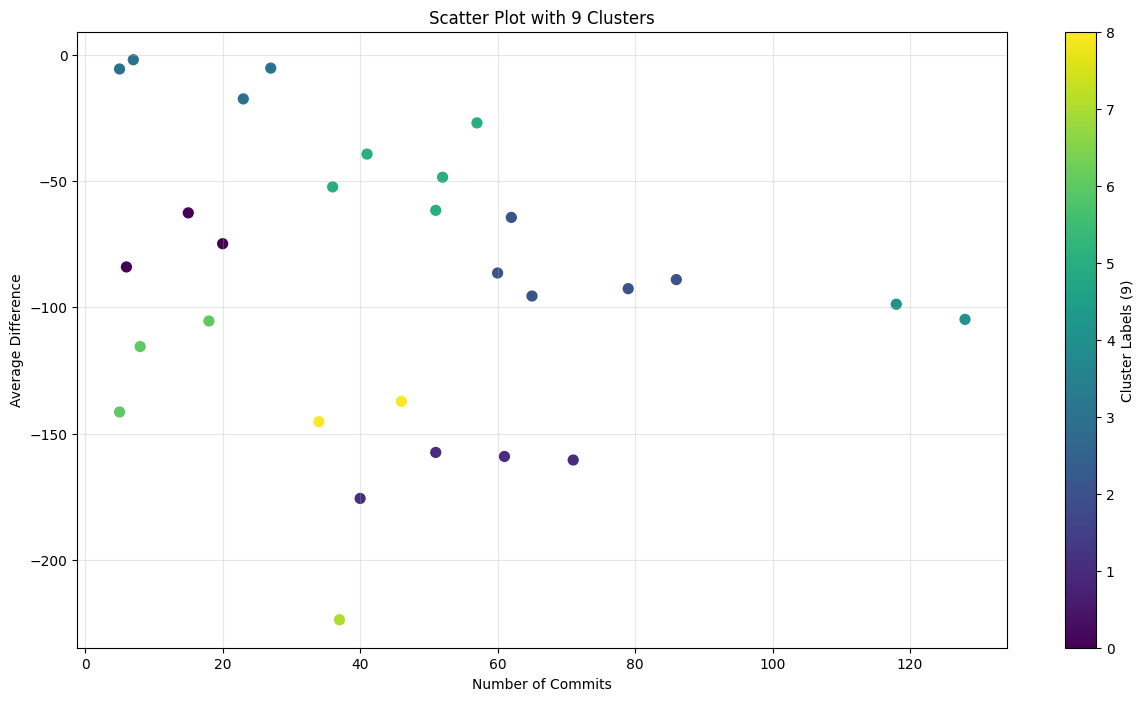

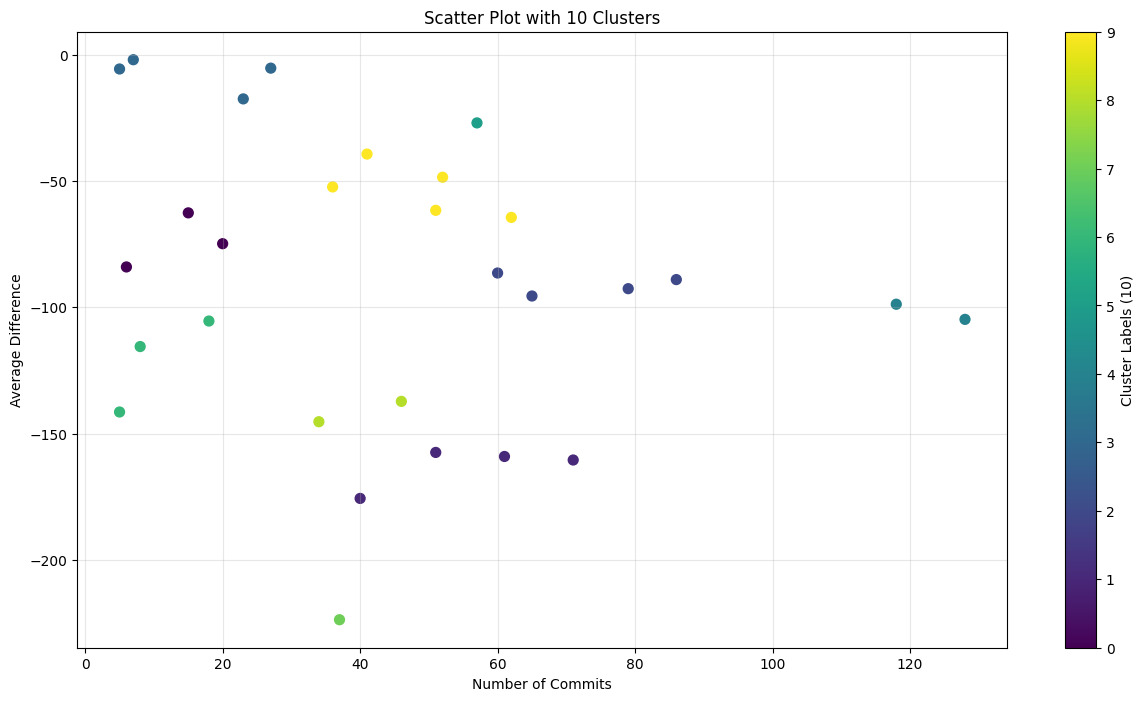

In [318]:
cluster_values = [4, 6, 7, 8, 9, 10]

for n_clusters in cluster_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=21)
    labels = kmeans.fit_predict(df)
    
    plt.figure(figsize=(15, 8))
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis', s=50)
    plt.xlabel('Number of Commits')
    plt.ylabel('Average Difference')
    plt.title(f'Scatter Plot with {n_clusters} Clusters')
    plt.colorbar(label=f'Cluster Labels ({n_clusters})')
    plt.grid(True, alpha=0.3)
    plt.show()

In [319]:
for n_clusters in cluster_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=21)
    labels = kmeans.fit_predict(df)
    silhouette_avg = silhouette_score(df, labels)
    print(f"Silhouette coefficient for {n_clusters} clusters: {silhouette_avg:.3f}")
    

Silhouette coefficient for 4 clusters: 0.415
Silhouette coefficient for 6 clusters: 0.395
Silhouette coefficient for 7 clusters: 0.396
Silhouette coefficient for 8 clusters: 0.486
Silhouette coefficient for 9 clusters: 0.454
Silhouette coefficient for 10 clusters: 0.426


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [320]:
dbscan = DBSCAN(eps=20, min_samples=2)
clusters = dbscan.fit_predict(df)
df['cluster_dbscan'] = clusters

display(df)

,num_commits,AVG(diff),cluster_dbscan
0,62,-64.400000,0
1,20,-74.800000,1
2,61,-159.000000,2
3,51,-61.600000,0
4,5,-5.666667,3
5,118,-98.750000,4
6,65,-95.500000,5
7,79,-92.600000,5
8,60,-86.400000,5
9,18,-105.400000,6


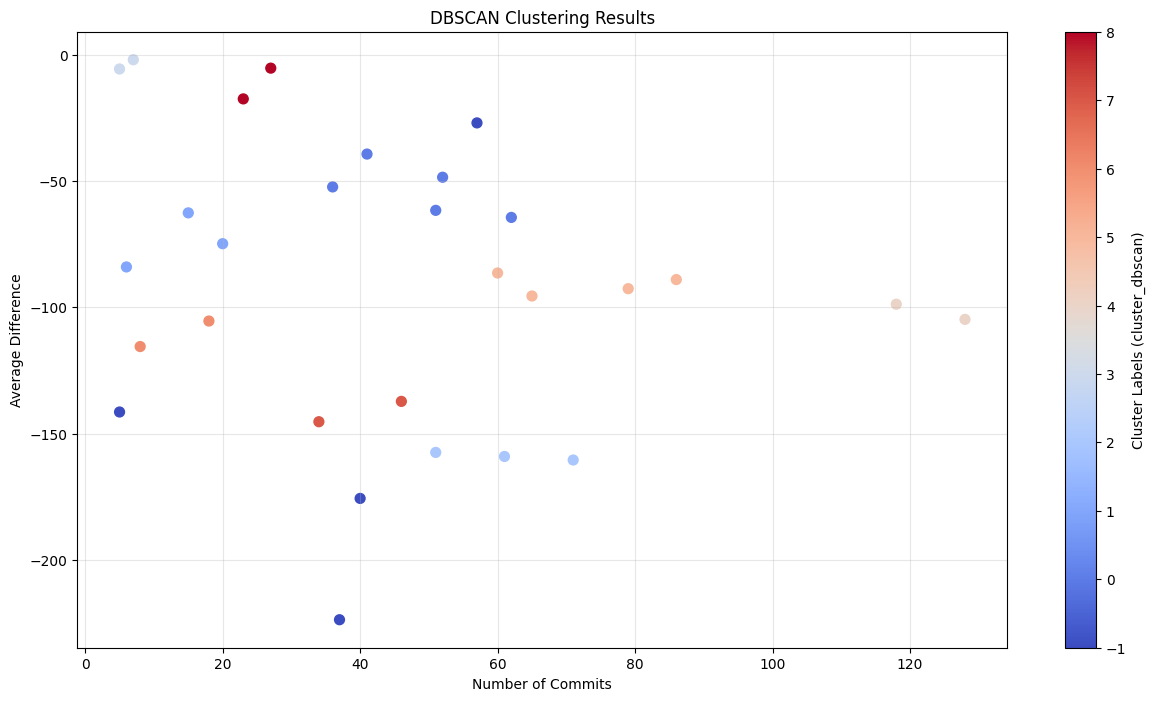

In [321]:
plt.figure(figsize=(15, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=df['cluster_dbscan'], cmap='coolwarm', s=50)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Number of Commits')
plt.ylabel('Average Difference')
plt.colorbar(label=f'Cluster Labels ({'cluster_dbscan'})')
plt.grid(True, alpha=0.3)
plt.show()

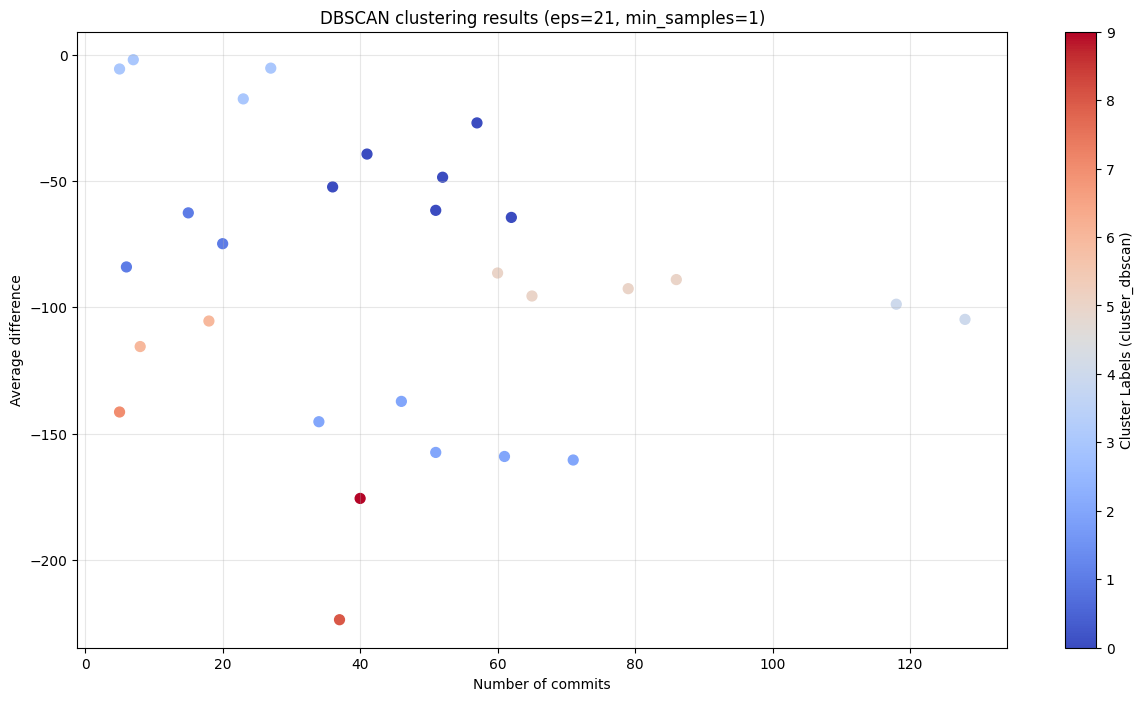

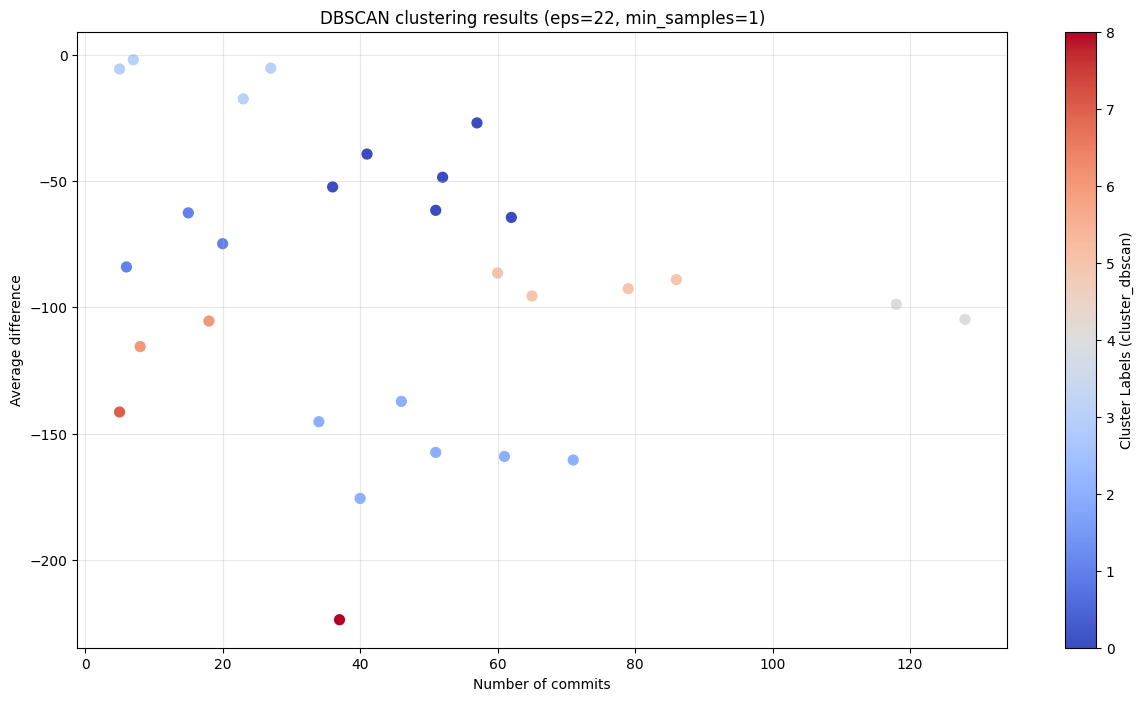

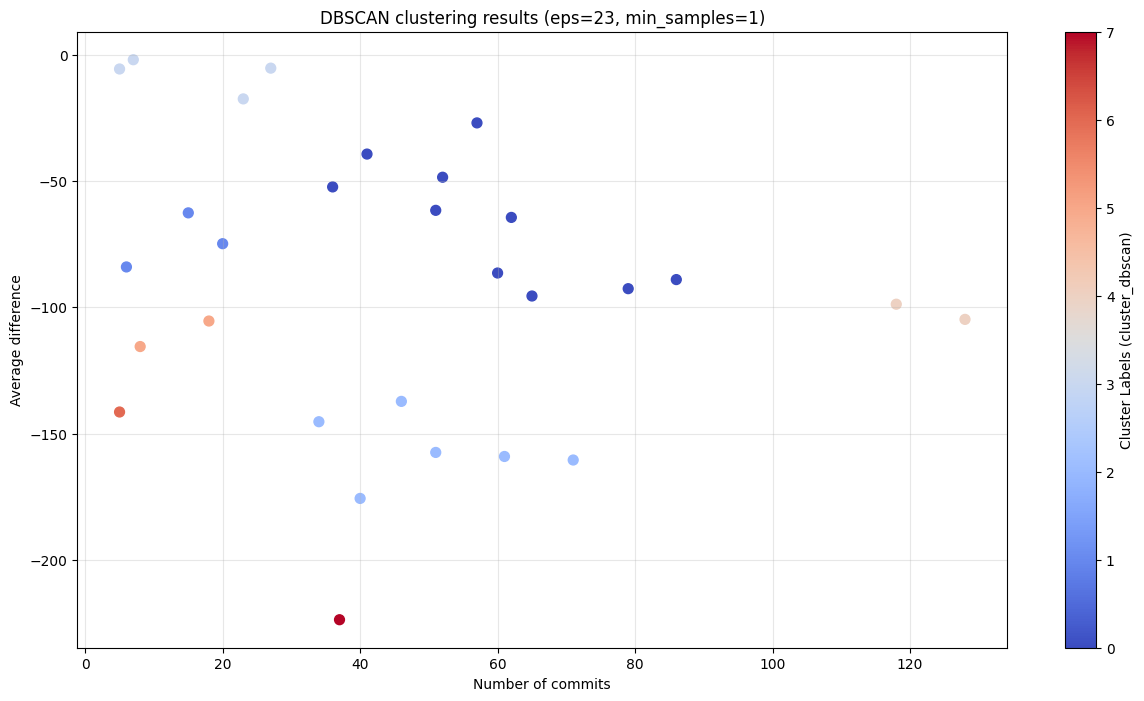

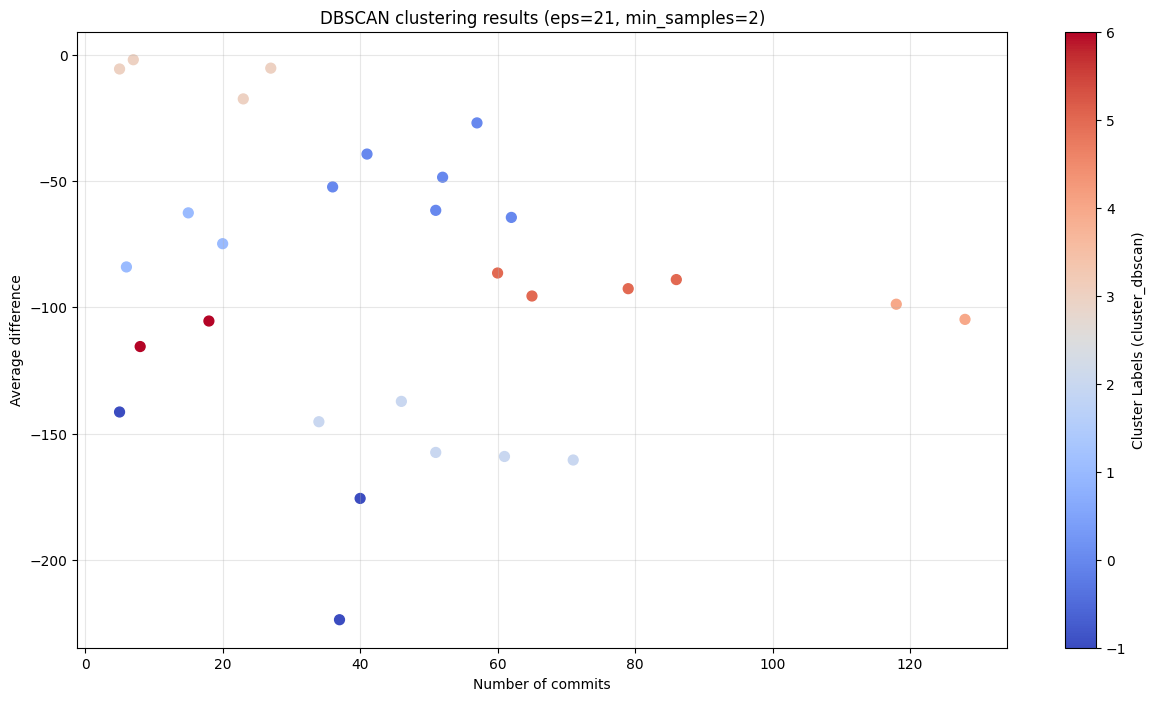

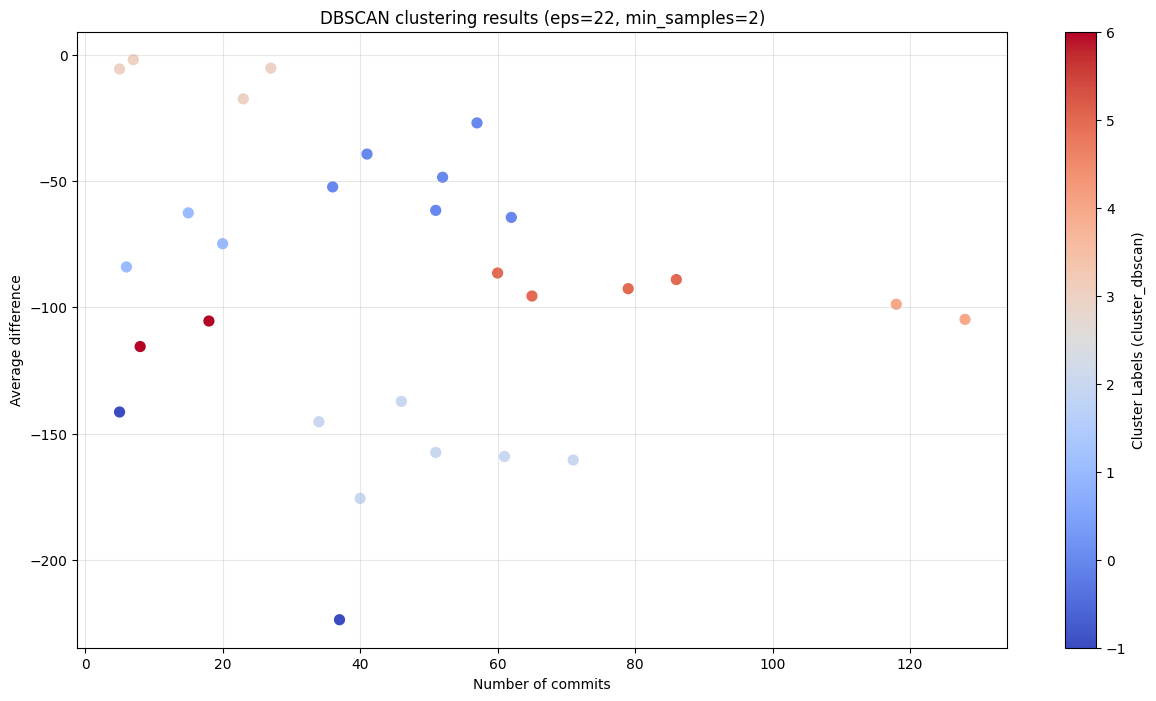

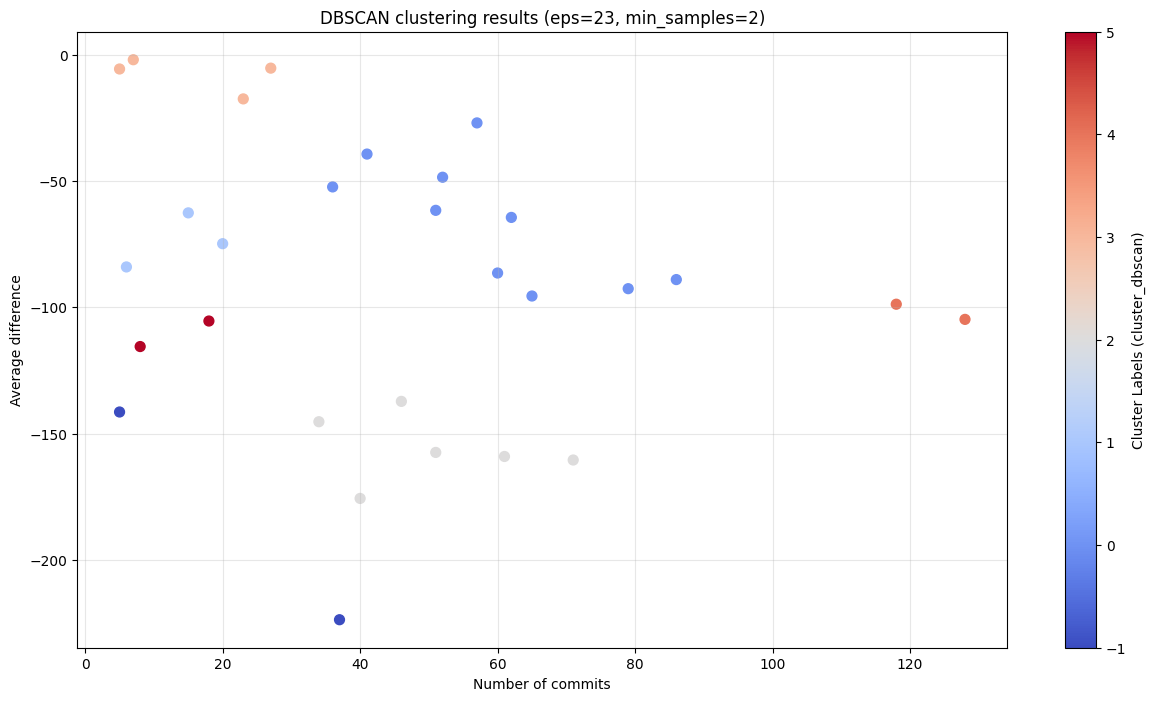

In [322]:
def visualize_dbsan(eps_val, min_samples_val):
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    clusters = dbscan.fit_predict(df[['num_commits', 'AVG(diff)']])
    
    plt.figure(figsize=(15, 8))
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters, cmap='coolwarm', s=50)
    plt.title(f'DBSCAN clustering results (eps={eps_val}, min_samples={min_samples_val})')
    plt.xlabel('Number of commits')
    plt.ylabel('Average difference')
    plt.colorbar(label=f'Cluster Labels ({'cluster_dbscan'})')
    plt.grid(True, alpha=0.3)
    plt.show()

tests = [
    {'eps': 21, 'min_samples': 1},
    {'eps': 22, 'min_samples': 1},
    {'eps': 23, 'min_samples': 1}, 
    {'eps': 21, 'min_samples': 2},
    {'eps': 22, 'min_samples': 2},
    {'eps': 23, 'min_samples': 2},
]

for test in tests:
    visualize_dbsan(test['eps'], test['min_samples'])

In [323]:
results = []
for test in tests:
    dbscan = DBSCAN(eps=test['eps'], min_samples=test['min_samples'])
    clusters = dbscan.fit_predict(df[['num_commits', 'AVG(diff)']])
    
    if len(set(clusters)) > 1: 
        score = silhouette_score(df[['num_commits', 'AVG(diff)']], clusters)
        results.append((test['eps'], test['min_samples'], score))
    else:
        results.append((test['eps'], test['min_samples'], None))
        
print("\nResults:")
for res in results:
    print(f"EPS: {res[0]}, Min Samples: {res[1]} => Silhouette Score: {res[2]:.3f}")


Results:
EPS: 21, Min Samples: 1 => Silhouette Score: 0.436
EPS: 22, Min Samples: 1 => Silhouette Score: 0.487
EPS: 23, Min Samples: 1 => Silhouette Score: 0.395
EPS: 21, Min Samples: 2 => Silhouette Score: 0.465
EPS: 22, Min Samples: 2 => Silhouette Score: 0.479
EPS: 23, Min Samples: 2 => Silhouette Score: 0.388


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [324]:
clustering = AgglomerativeClustering(n_clusters=5)
labels = clustering.fit_predict(df)
display(labels)

array([2, 3, 0, 2, 4, 1, 1, 1, 1, 3, 0, 4, 1, 2, 4, 2, 0, 2, 3, 3, 0, 2,
       4, 0, 1, 0, 3, 3, 0])

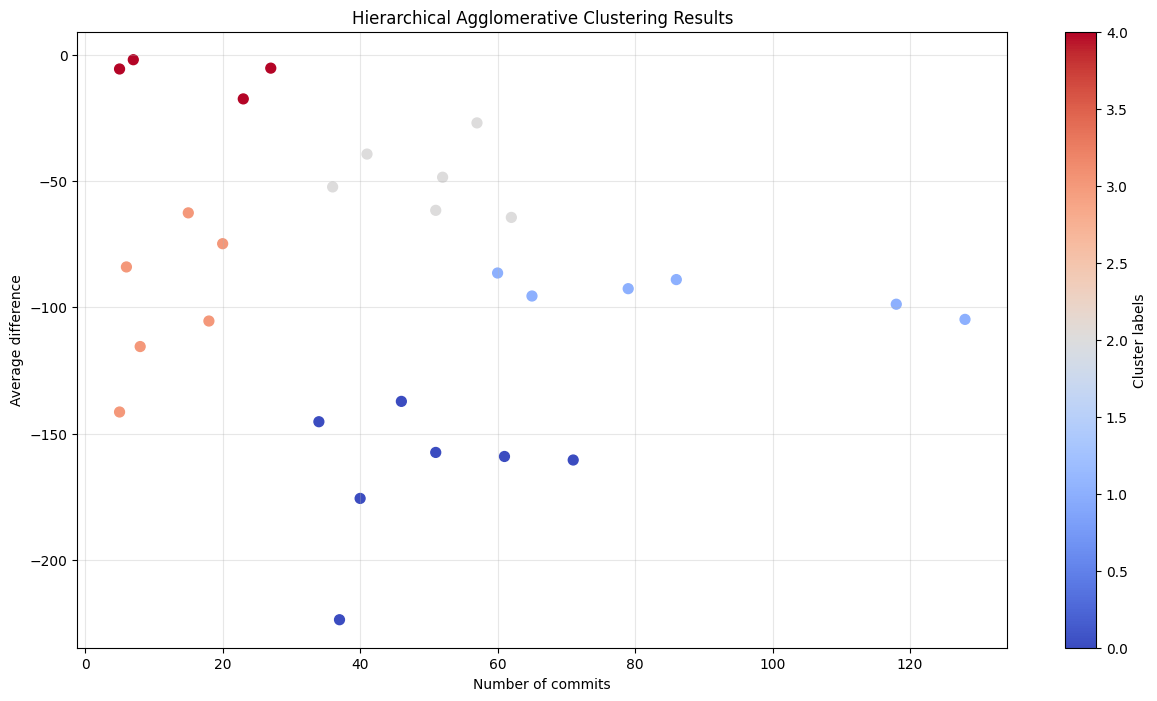

In [325]:
plt.figure(figsize=(15, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='coolwarm', s=50)
plt.title('Hierarchical Agglomerative Clustering Results')
plt.xlabel('Number of commits')
plt.ylabel('Average difference')
plt.colorbar(label='Cluster labels')
plt.grid(True, alpha=0.3)
plt.show()

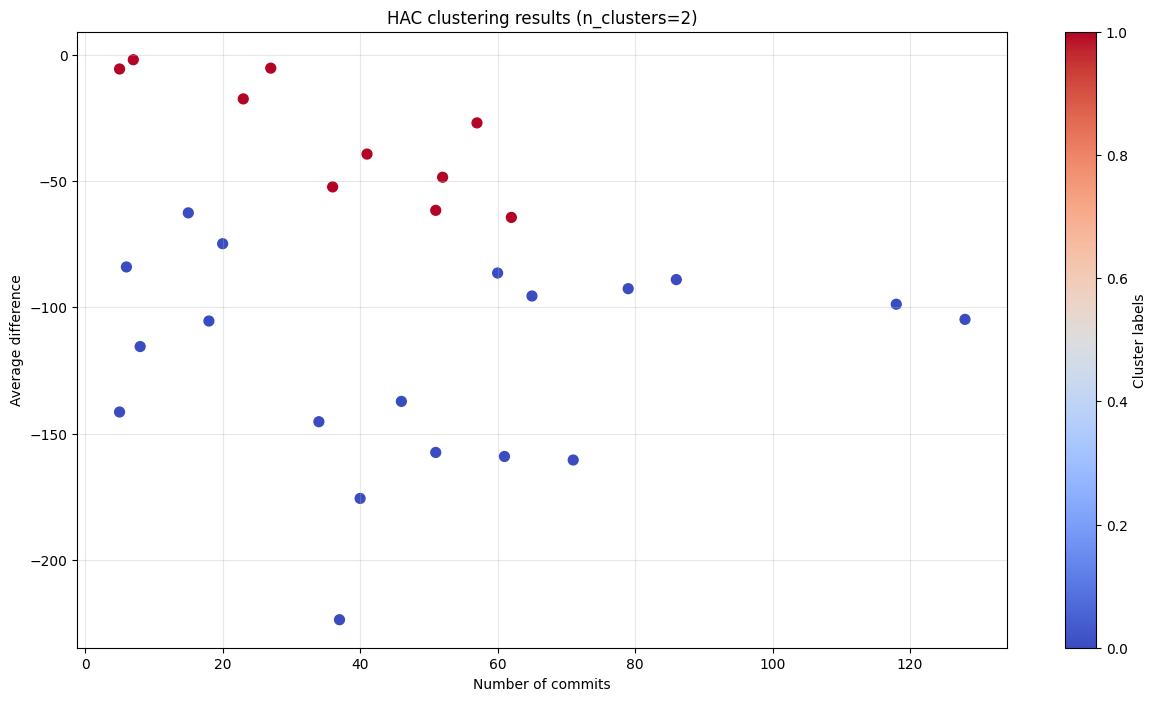

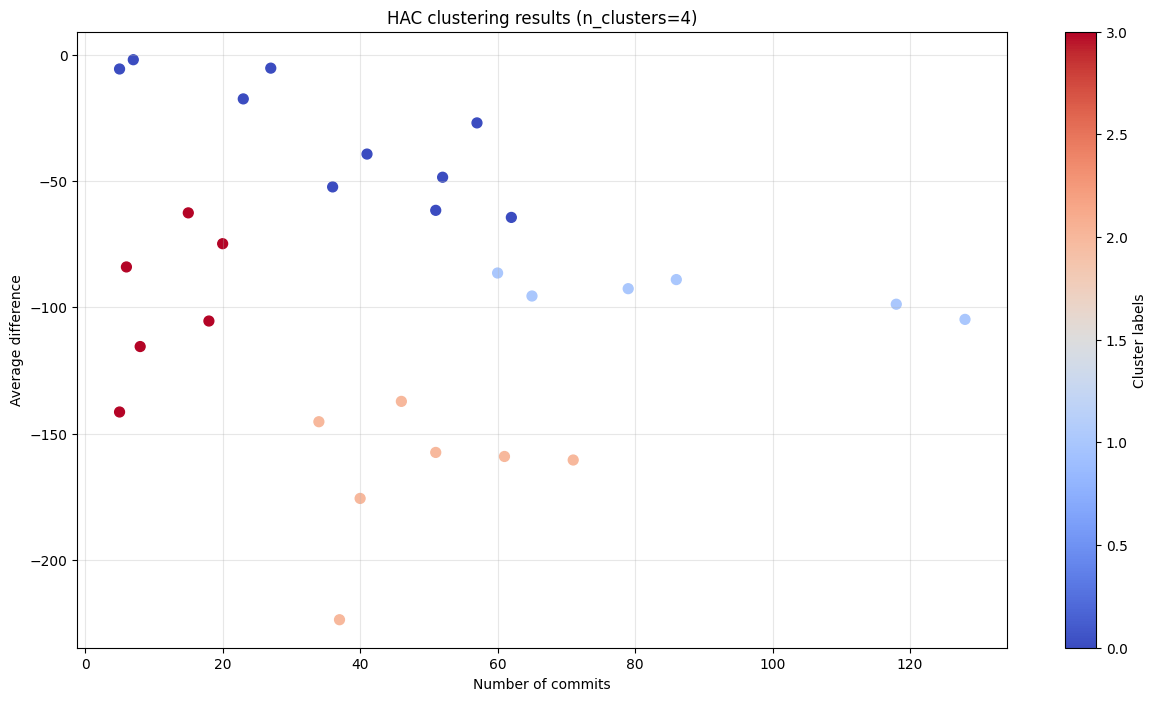

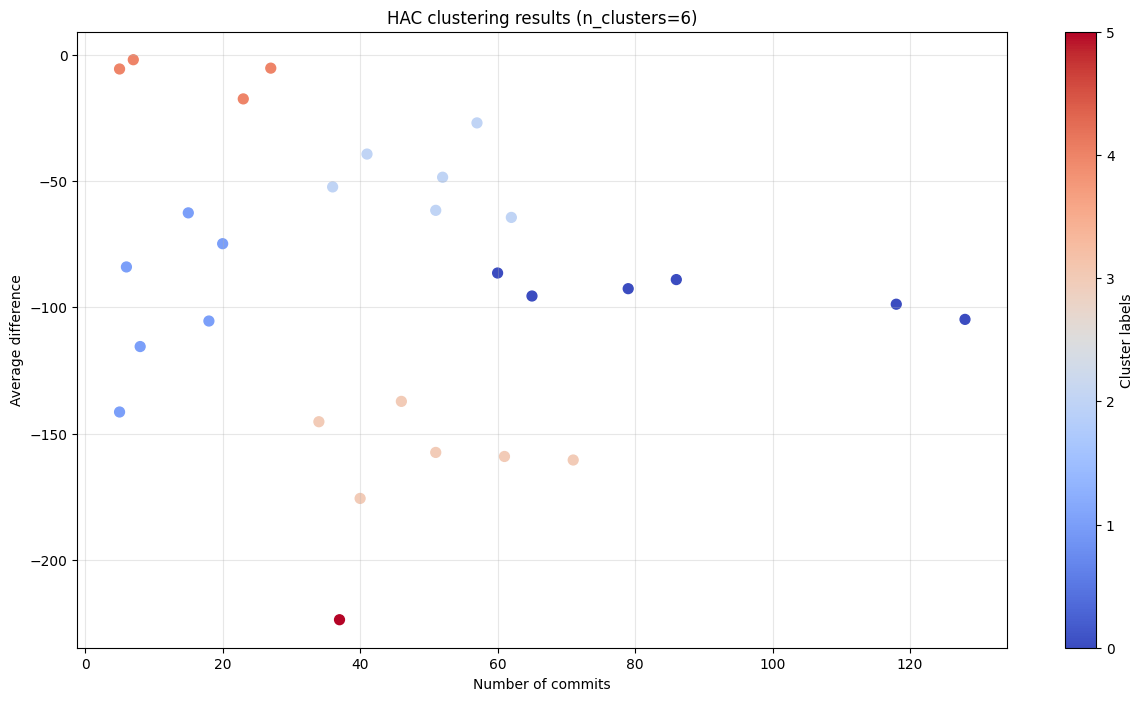

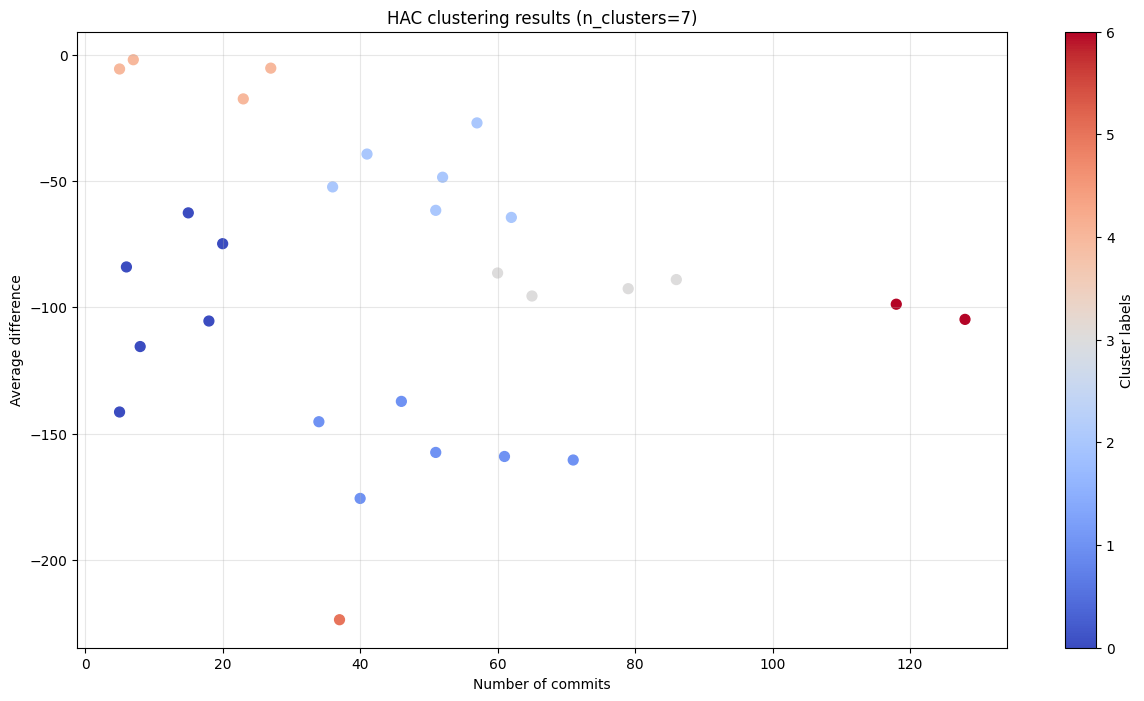

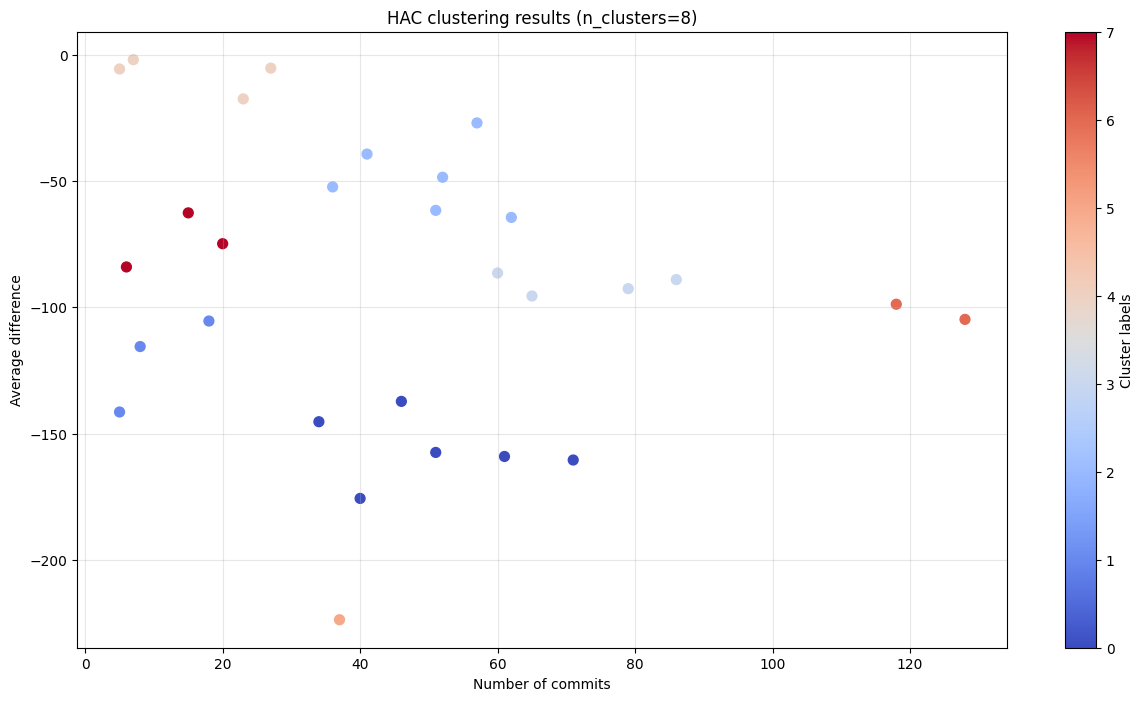

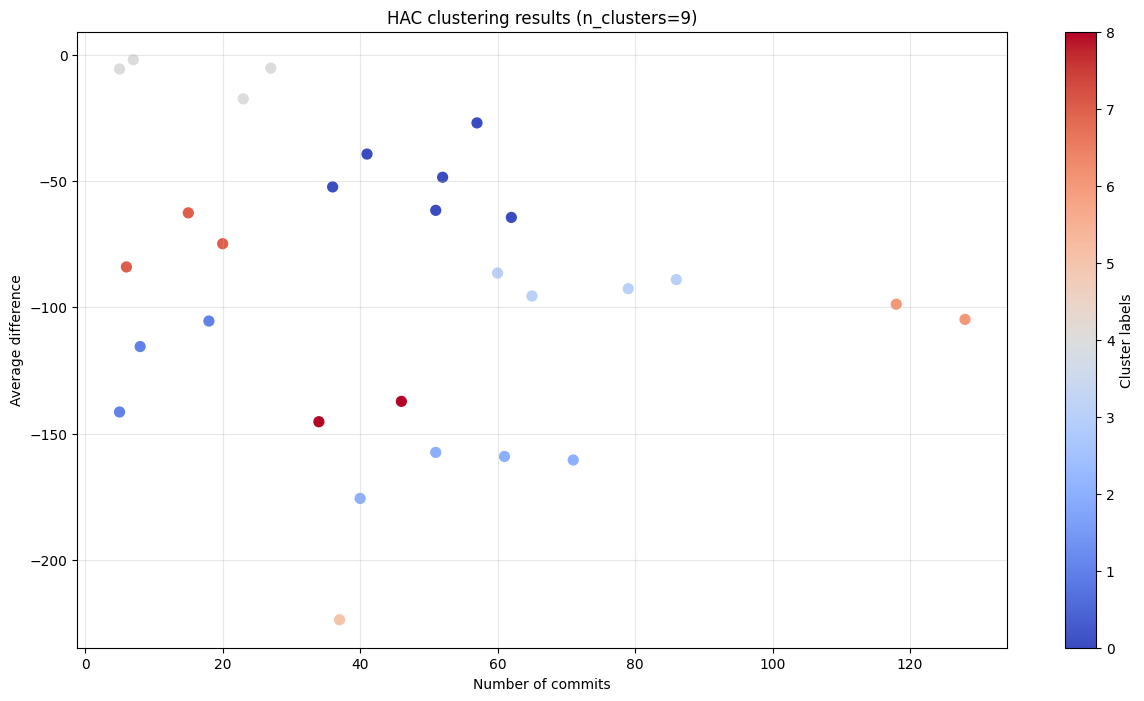

In [326]:
def visualize_hac(n_clusters_val):
    hac = AgglomerativeClustering(n_clusters=n_clusters_val, linkage='ward')
    labels = hac.fit_predict(df[['num_commits', 'AVG(diff)']])

    plt.figure(figsize=(15, 8))
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='coolwarm', s=50)
    plt.title(f'HAC clustering results (n_clusters={n_clusters_val})')
    plt.xlabel('Number of commits')
    plt.ylabel('Average difference')
    plt.colorbar(label='Cluster labels')
    plt.grid(True, alpha=0.3)
    plt.show()
    
clusters_val = [2, 4, 6, 7, 8, 9]
for val in clusters_val:
    visualize_hac(val)

In [327]:
for val in clusters_val:
    hac = AgglomerativeClustering(n_clusters=val, linkage='ward')
    labels = hac.fit_predict(df)
    score = silhouette_score(df, labels)
    print(f"Silhouette Score for n_clusters={val}: {score:.3f}")

Silhouette Score for n_clusters=2: 0.358
Silhouette Score for n_clusters=4: 0.443
Silhouette Score for n_clusters=6: 0.452
Silhouette Score for n_clusters=7: 0.486
Silhouette Score for n_clusters=8: 0.507
Silhouette Score for n_clusters=9: 0.479


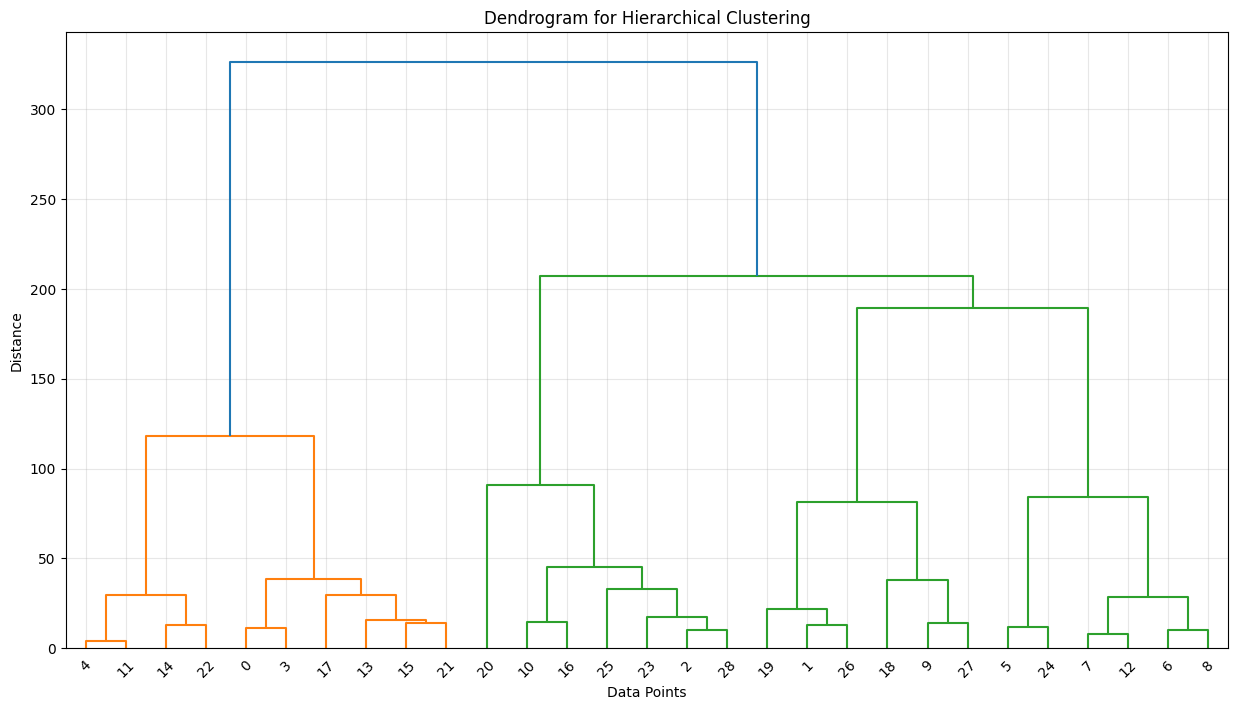

In [328]:
z = linkage(df, method='ward')

plt.figure(figsize=(15, 8))
dn = dendrogram(z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

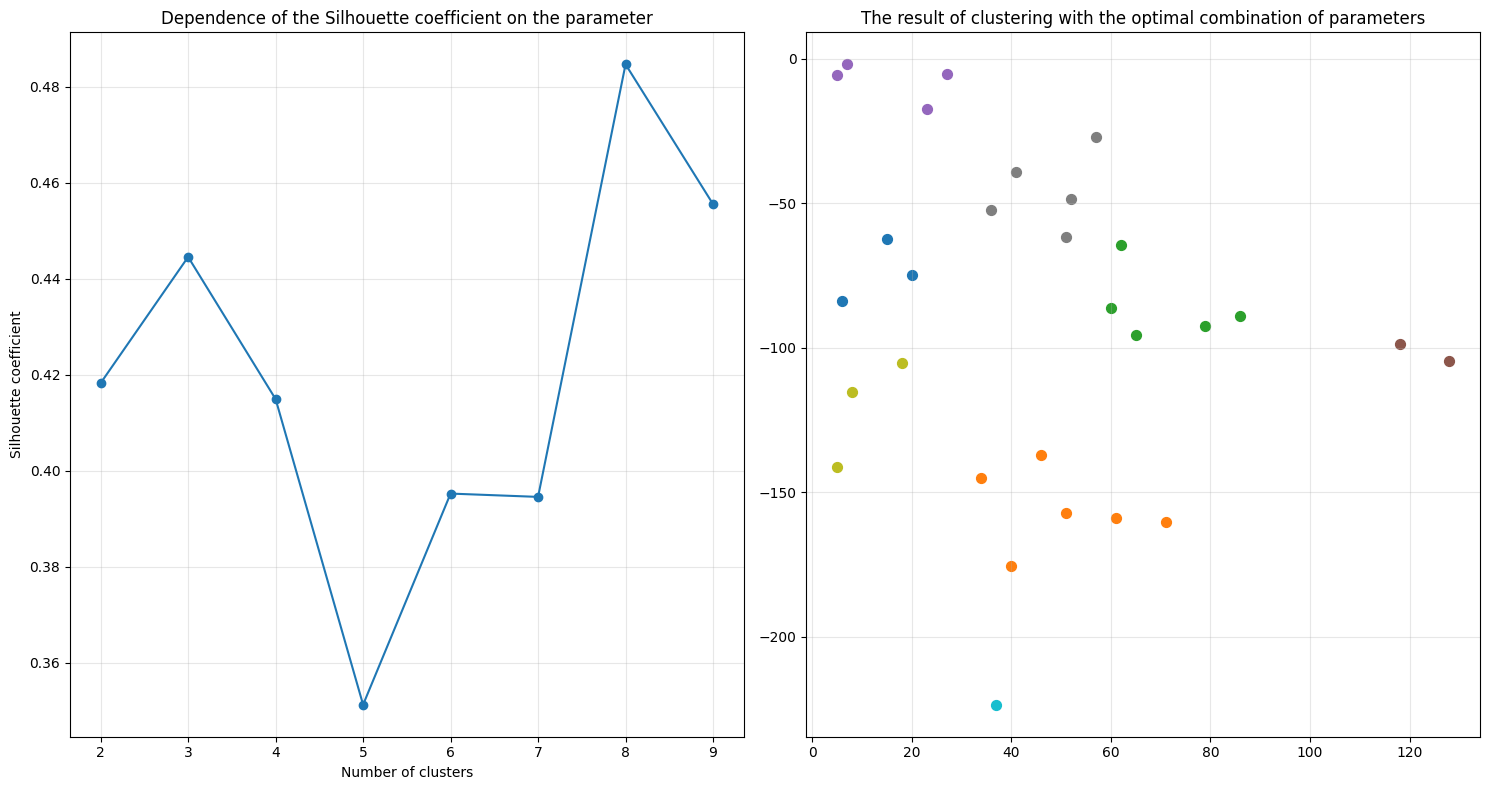

Best number of clusters (K-means): 8


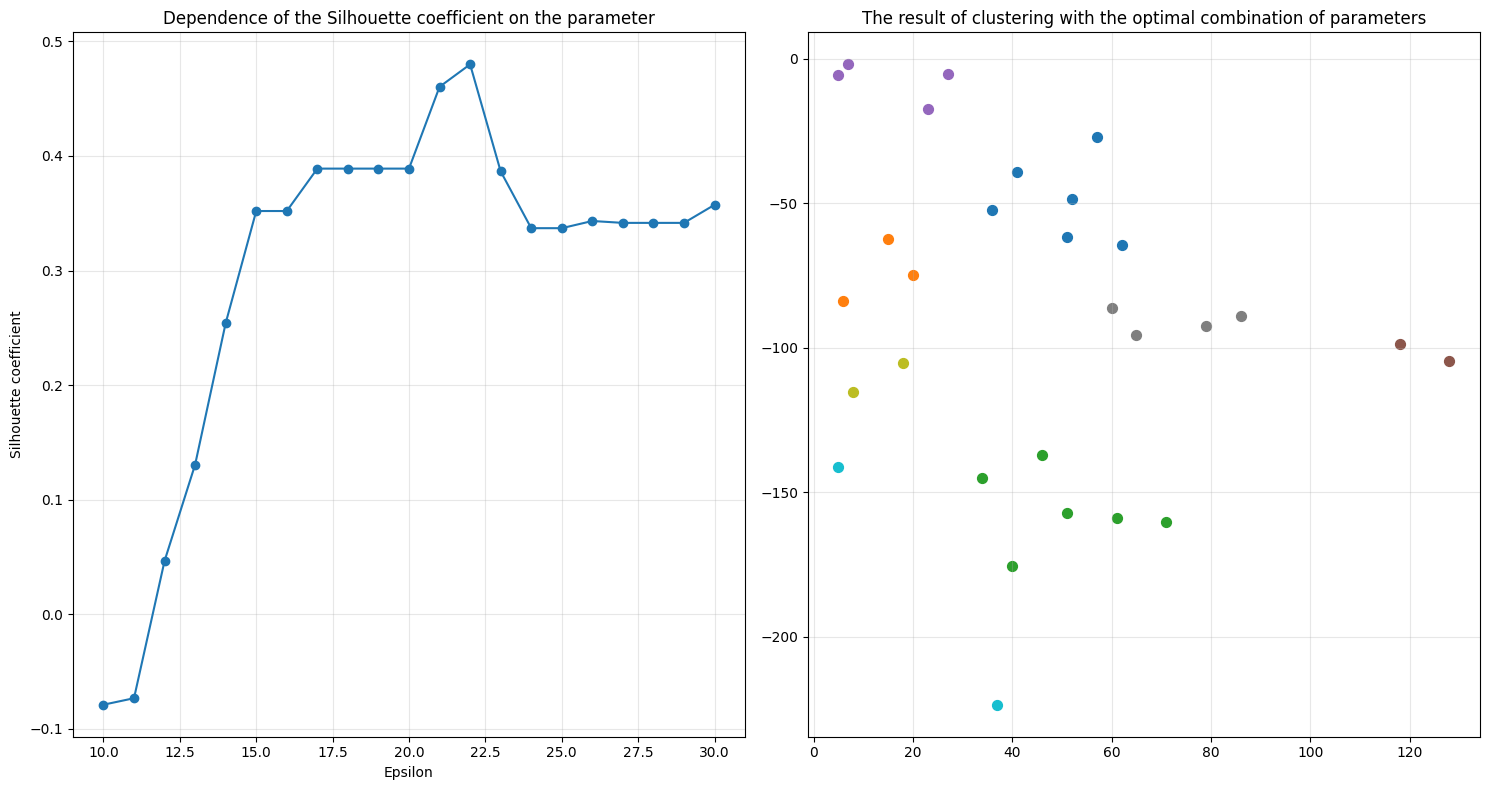


Best eps for DBSCAN: 22 | Silhouette factor: 0.4800



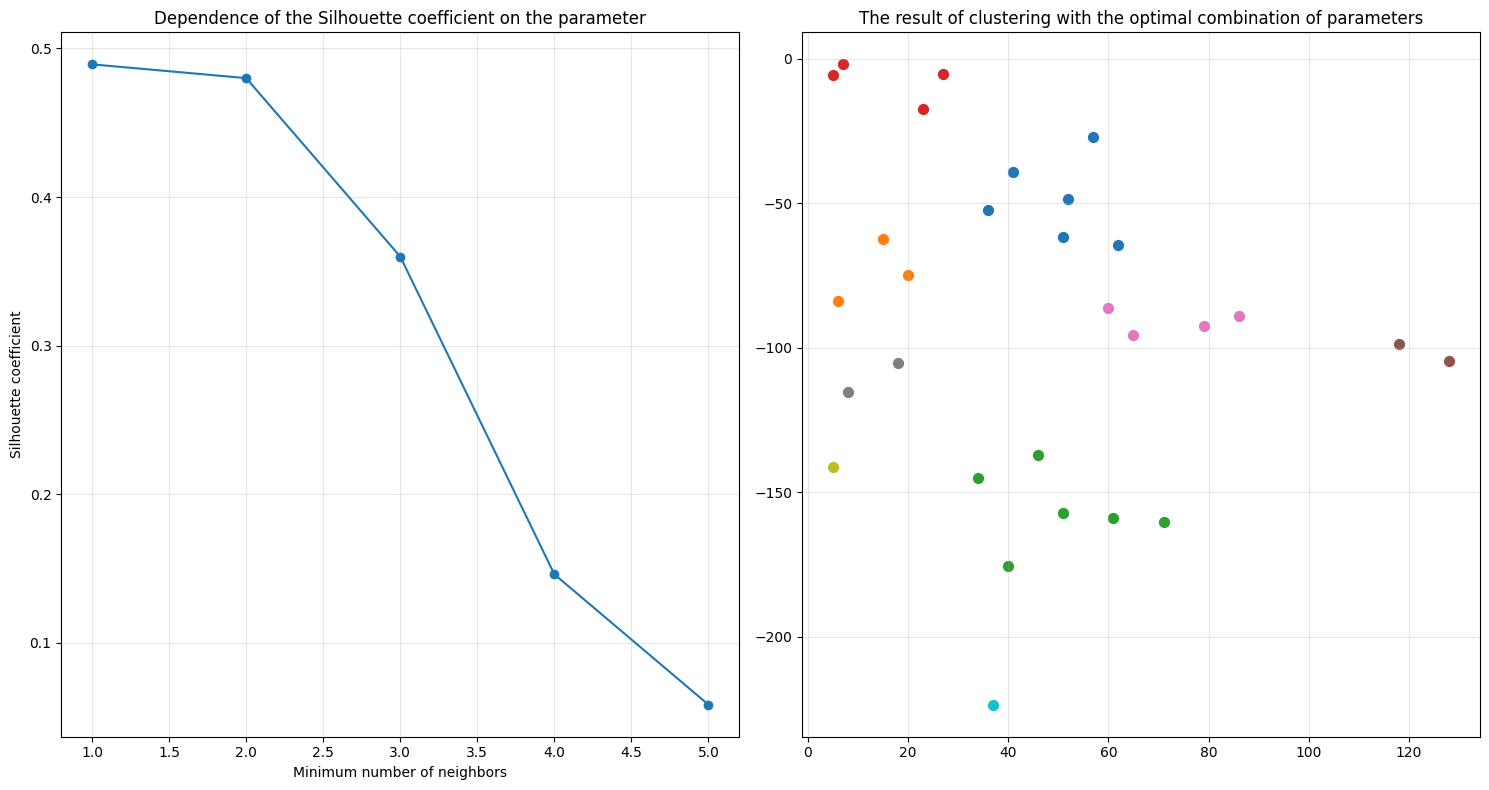

Best min_samples for DBSCAN: 1 | Silhouette factor: 0.4893



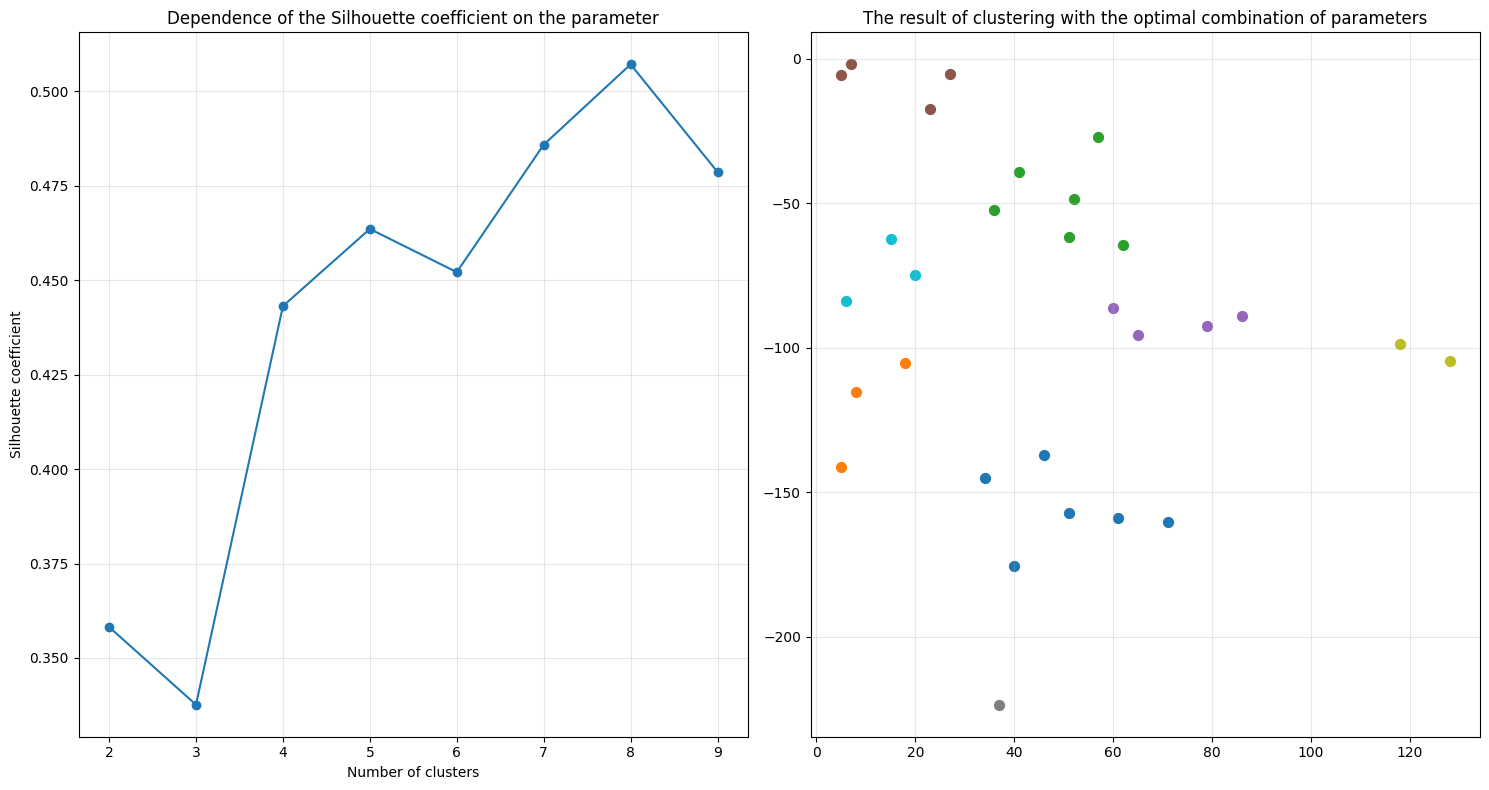

Optimal number of clusters (Agglomerative clustering): 8


In [337]:
def evaluate_clustering(model, data):
    labels = model.fit_predict(data)
    return silhouette_score(data, labels)

def find_best_parameter_combination(model_class, parameters, param_names, ranges_list, data):
    best_score = -np.inf
    best_values = {}
    results = []

    for combo in product(*ranges_list):
        temp_params = parameters.copy()
        for idx, val in enumerate(combo):
            temp_params[param_names[idx]] = val
        model = model_class(**temp_params)
        current_score = evaluate_clustering(model, data)
        results.append((combo, current_score))
        if current_score > best_score:
            best_score = current_score
            best_values = dict(zip(param_names, combo))
    return best_values, best_score, results

def visualize_results(best_values, results, data, param_name, model_class, parameters):
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    plt.title("Dependence of the Silhouette coefficient on the parameter")
    plt.xlabel(param_name)
    plt.ylabel("Silhouette coefficient")
    plt.grid(True, alpha=0.3) 
    sorted_results = sorted(results, key=lambda x: x[0][0])
    plt.plot([res[0][0] for res in sorted_results], [res[1] for res in sorted_results], marker="o")
    plt.subplot(1, 2, 2)
    plt.title("The result of clustering with the optimal combination of parameters")

    optimized_model = model_class(**{**parameters, **best_values})
    labels = optimized_model.fit_predict(data)
    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        cluster_data = data[labels == label]
        plt.scatter(cluster_data[:, 0], cluster_data[:, 1], s=50, c=[color])
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

data = df.values  

kmeans_params = {'n_clusters': None, 'max_iter': 300, 'init': 'k-means++', 'random_state': 21}
best_kmeans_param, _, results = find_best_parameter_combination(KMeans, 
    kmeans_params, ['n_clusters'], [range(2, 10)], data)
visualize_results(best_kmeans_param, results, data, 'Number of clusters', KMeans, kmeans_params)
print(f"Best number of clusters (K-means): {best_kmeans_param['n_clusters']}")

best_eps, best_eps_sc, results_eps = find_best_parameter_combination(
    DBSCAN, {"min_samples": 2}, ["eps"], [np.arange(10, 31)], data)
visualize_results(best_eps, results_eps, data, 'Epsilon', DBSCAN, {"min_samples": 2})
print(f"\nBest eps for DBSCAN: {best_eps['eps']} | Silhouette factor: {best_eps_sc:.4f}\n")


best_min_samples, best_min_samples_sc, results_min_samples = find_best_parameter_combination(
    DBSCAN, {"eps": best_eps['eps']}, ["min_samples"], [range(1, 6)], data)
visualize_results(best_min_samples, results_min_samples, data, 'Minimum number of neighbors',
    DBSCAN, {"eps": best_eps['eps']})
print(f"Best min_samples for DBSCAN: {best_min_samples['min_samples']} | Silhouette factor: {best_min_samples_sc:.4f}\n")

hac_params = {'n_clusters': None, 'linkage': 'ward'}
best_hac_param, _, results = find_best_parameter_combination(AgglomerativeClustering, hac_params, ['n_clusters'], [range(2, 10)], data)
visualize_results(best_hac_param, results, data, 'Number of clusters', AgglomerativeClustering, hac_params)
print(f"Optimal number of clusters (Agglomerative clustering): {best_hac_param['n_clusters']}")